# 들어가며  

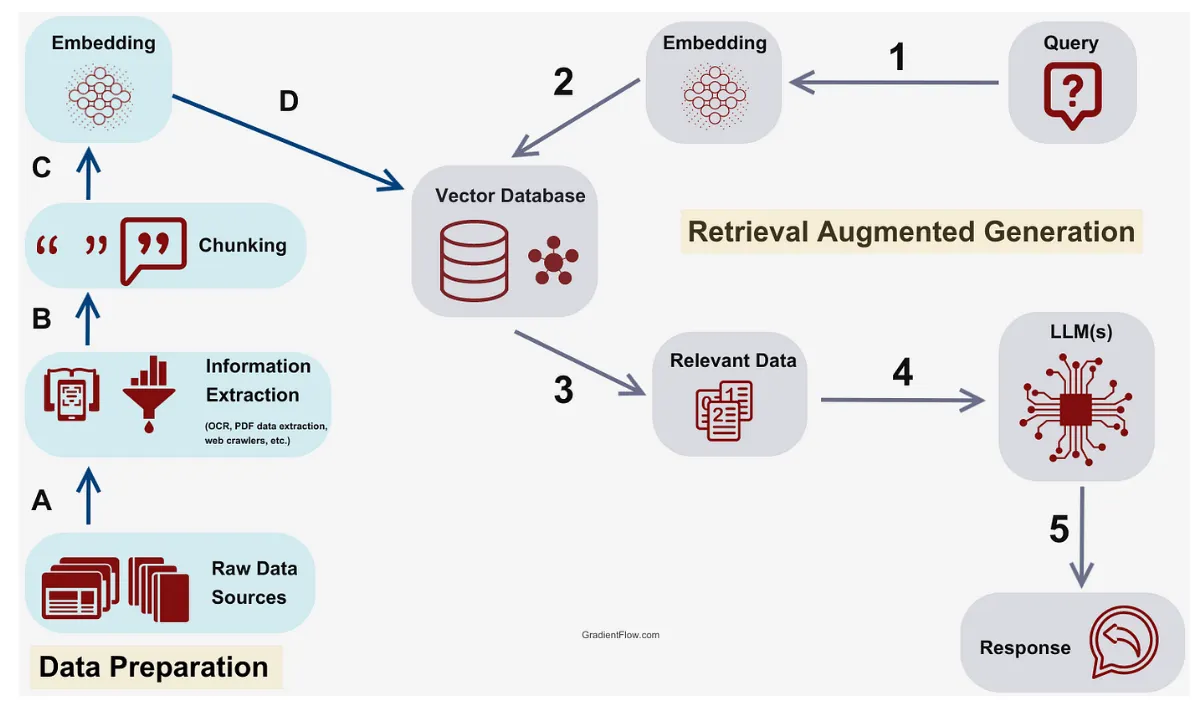

초기 단계의 검색 증강 생성 기술인 Naive RAG는 대규모 언어 모델(LLM)이 가진 고질적인 정보 부재 문제를 해결하기 위해 도입되었습니다. 이 시스템의 핵심은 외부 데이터 소스를 일종의 '참조 라이브러리'로 활용하는 것입니다.  

**Naive RAG의 메커니즘과 활용**  
일반적인 LLM이 학습 데이터 내의 지식에만 의존한다면, Naive RAG는 특정 분야의 전문 데이터(예: PDF 형식의 복잡한 보험 약관이나 상세한 보상 규정 등)를 실시간으로 탐색합니다. 사용자가 질문을 던지면 시스템은 미리 준비된 문서 더미에서 관련도가 높다고 판단되는 조각을 찾아내어, 이를 바탕으로 상세한 응답을 재구성합니다.

**초기 모델의 기술적 한계**  
하지만 이러한 방식은 단순한 수치적 유사성에 지나치게 의존한다는 맹점이 있었습니다. 단어들을 수치(벡터)로 변환한 뒤 그 거리만을 계산하다 보니, 겉보기엔 비슷해 보여도 실제 문맥이나 심층적인 의미는 전혀 다른 정보가 검색 결과에 섞여 들어오는 경우가 잦았습니다. 결과적으로 다음과 같은 부작용이 발생하곤 했습니다.

- 검색 단계의 딜레마 (Retrieval Challenges)
데이터 저장소에서 정보를 추출할 때, 시스템은 **정밀도(Precision)** 와 재현율(Recall) 사이에서 고전합니다.

    - 정보의 미스매치: 질문의 의도와 어긋난 부적절한 텍스트 조각(Chunk)을 선택하거나, 정작 답변에 꼭 필요한 핵심 정보를 놓치는 경우가 빈번합니다.

    - 노이즈 유입: 검색 알고리즘의 한계로 인해 질문과 상관없는 '잡음' 데이터가 포함되어 이후 생성 단계에 혼선을 줍니다.

- 생성 공정의 리스크 (Generation Difficulties)
검색된 데이터를 바탕으로 문장을 엮어내는 과정에서도 품질 저하 요소가 발생합니다.

    - 환각 현상(Hallucination): 가장 치명적인 문제로, 모델이 검색된 맥락에 근거하지 않은 가공의 사실을 유포하는 현상입니다.

    - 윤리적 결함: 추출된 정보의 편향성이나 독성(Toxicity)이 걸러지지 않고 답변에 그대로 투영되어 결과물의 객관성을 해칠 수 있습니다.

-  지식 통합 및 증강의 장애 (Augmentation Hurdles)
검색된 파편화된 정보를 기존의 작업 모델과 매끄럽게 결합하는 것은 매우 까다로운 작업입니다.

    - 응집력 부족: 서로 다른 소스에서 가져온 정보들이 유기적으로 연결되지 않아 답변이 산만하거나 논리적 일관성이 떨어질 수 있습니다.

    - 정보의 과잉과 중복: 여러 문서에서 유사한 내용이 반복적으로 검색될 경우, 최종 답변이 같은 말을 되풀이하는 비효율적인 구조를 갖게 됩니다.

    - 톤 앤 매너의 불일치: 외부 문서의 문체와 AI의 답변 톤이 충돌하여 사용자에게 이질감을 줍니다.

-  구조적 복잡성 및 의존성 문제
단 한 번의 단순 쿼리(Query)만으로는 복잡한 질문에 필요한 충분한 맥락을 확보하기 어렵습니다. 또한, 생성 모델이 검색된 정보에 **과도하게 의존(Over-reliance)** 하는 경향도 문제입니다. 이는 AI가 스스로의 논리적 판단을 배제하고, 단순히 검색된 텍스트를 복사하듯 되풀이하는(Echoing) 결과를 초래하여 지능적인 답변 생성을 방해합니다.

이를 해결하기 위한 두 개의 패러다임, Advanced RAG 와 Modular RAG를 소개합니다.  

## Advanced RAG: 성능과 효율의 균형 잡기

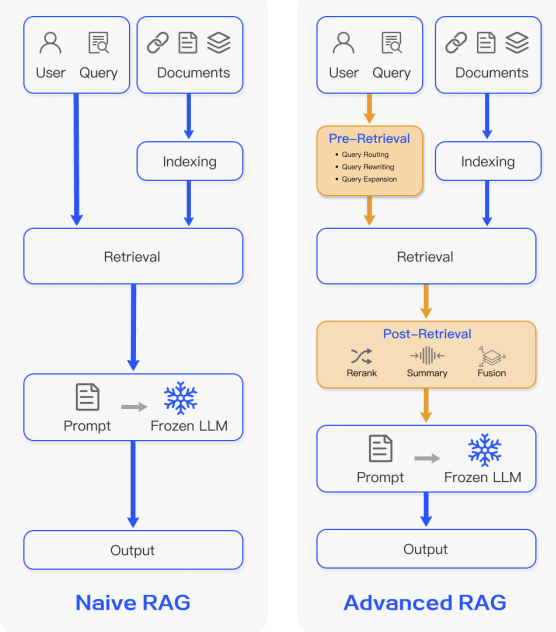

이러한 검색의 노이즈를 제거하고 정확도를 극대화하기 위해 등장한 것이 Advanced RAG입니다. 이 모델은 단순히 텍스트의 표면적 유사도를 비교하는 수준을 넘어, 보다 정밀한 전처리 과정과 정교한 검색 알고리즘을 도입했습니다.

Advanced RAG는 쿼리(질문)와 문서 사이의 입체적인 맥락을 분석하며, 검색된 정보가 실제로 답변 생성에 얼마나 유효한지를 다시 한번 검증하는 기술적 장치들을 포함합니다. 이를 통해 사용자는 훨씬 더 신뢰할 수 있고 맥락에 부합하는 정교한 결과물을 얻을 수 있게 되었습니다.

**Indexing Refinement : 인덱싱 최적화**  
데이터가 모델에게 잘 읽히도록 구조화하는 것이 첫 번째 단계입니다.

- 슬라이딩 윈도우(Sliding Window): 문장을 겹치게 자르는 기술입니다. 문맥이 중간에 끊기지 않도록 앞뒤 내용을 중첩시켜 정보의 연속성을 유지합니다.  

- 메타데이터 활용: 텍스트에 날짜, 작성자, 핵심 키워드 같은 '라벨'을 붙여 검색의 정밀도를 극대화합니다.  

- 데이터 세분화(Granularity): 정보를 너무 크게 뭉치지 않고, 의미 있는 최소 단위로 정교하게 쪼개어 검색 효율을 높입니다.  

**Pre-retrieval: 검색 전 최적화**  
- Semantic Chunking (의미론적 청킹):
단순히 글자 수로 자르면 문맥이 끊깁니다. 최신 기법은 문장 간의 유사도를 측정하여 의미가 급격히 변하는 지점에서 자릅니다.
LangChain의 SemanticChunker를 사용하면 법률이나 기술 문서처럼 구조가 복잡한 데이터에서도 정보 손실을 최소화할 수 있습니다.  
- Query Expansion & Rewriting (질문 확장 및 재작성):  
사용자의 질문이 짧거나 모호할 때, LLM을 이용해 검색에 유리한 3~5개의 다른 질문으로 확장(Multi-Query)합니다.  
LLM을 한 번 더 쓰면 느려지지 때문에, 질문 재작성에는 가벼운 모델(예: Claude Haiku)을 사용하여 속도를 확보하고, 최종 답변에만 고성능 모델을 사용하는 전략을 씁니다.  



**Post-retrieval Process : 정보의 정제와 배치**  
관련 문서를 찾았다고 끝이 아닙니다. AI 모델이 읽기 편하도록 가장 '맛있는 부분'만 골라내는 과정입니다.

- Re-ranking: 검색된 여러 문서 조각 중, 실제 정답에 가까운 순서로 다시 정렬합니다. 특히 중요한 정보를 프롬프트의 앞쪽이나 뒤쪽(Edges)에 배치하여 모델의 집중력을 높입니다. LlamaIndex, LangChain 등 주요 프레임워크의 필수 기능입니다.

- Context Compression: 검색된 문서에서 질문과 상관없는 문장들을 쳐내고 핵심만 LLM에 넘깁니다. 이는 LLM의 토큰 비용을 절감하고, 중요 정보가 뒤섞여 답변 성능이 떨어지는 'Lost in the Middle' 현상을 방지합니다.

**번외 : 여러 Post-retrieval 전략**  
위에 소개한 Rerank가 적용되기까지, LLM의 답변을 개선시키기 위한 여러 Post-retreval process가 적용되어 왔습니다.  

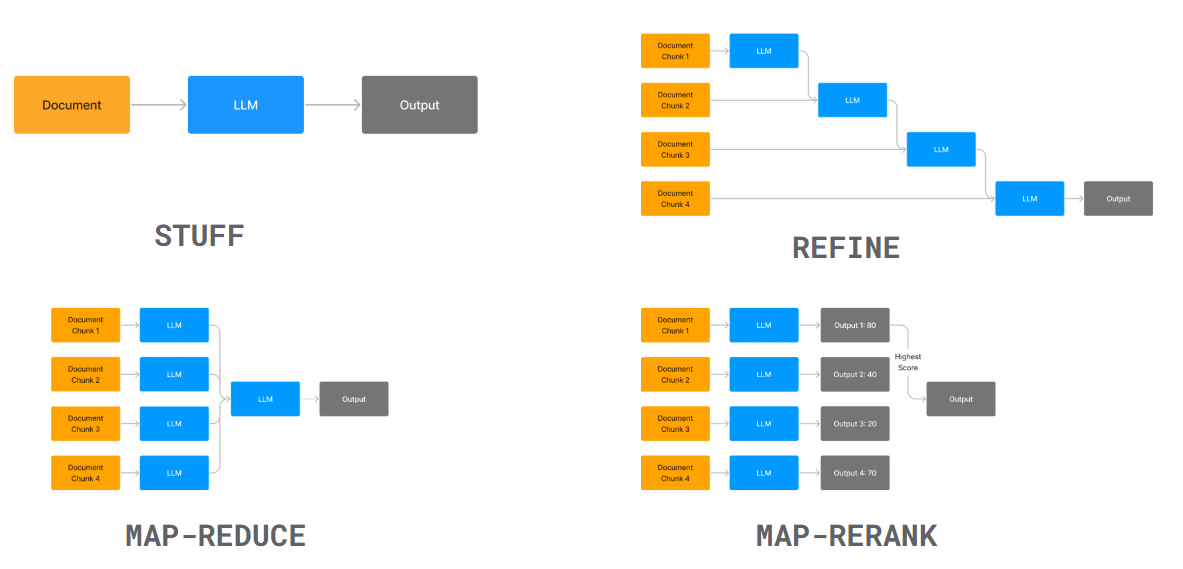

1. STUFF (쑤셔 넣기)
가장 단순하고 직관적인 방식입니다. 모든 관련 문서를 하나로 합쳐서 LLM에게 한꺼번에 던져주는 형태입니다.

    특징: 문서가 짧을 때 매우 빠르고 효율적입니다.

    장점: 문맥이 끊기지 않아 일관성 있는 답변을 얻을 수 있습니다.

    단점: 문서가 너무 길어지면 LLM의 입력 제한(Token Limit)을 초과하여 오류가 발생합니다.

2. REFINE (다듬기)
문서를 순차적으로 읽으며 답변을 점진적으로 업데이트하는 방식입니다.

    특징: 첫 번째 조각(Chunk 1)으로 초안 답변을 만들고, 두 번째 조각을 읽으며 초안을 수정(Refine)하며 끝까지 반복합니다.

    장점: 앞선 맥락을 계속 유지하면서 답변을 정교하게 다듬을 수 있습니다.

    단점: 순차적 처리 방식이라 속도가 느리고, 중간에 맥락이 왜곡될 위험이 있습니다.

3. MAP-REDUCE (분할 후 병합)
각 문서 조각을 개별적으로 처리한 뒤, 그 결과물들을 모아서 최종 요약을 만드는 방식입니다.

    1. Map: 각 조각에 대해 독립적으로 LLM이 답변을 생성합니다.
    2. Reduce: 생성된 여러 답변을 다시 하나로 합쳐 최종 답변을 도출합니다.

    장점: 각 조각을 동시에 처리(병렬 처리)할 수 있어 속도가 매우 빠릅니다.

    단점: 각 조각을 따로 처리하다 보니, 문서 전체를 아우르는 통합적인 맥락을 놓칠 수 있습니다.

4. MAP-RERANK (점수 매기기 및 순위화)
각 문서 조각에서 답변을 추출한 뒤, 가장 신뢰도가 높은 답변을 선택하는 방식입니다.

    특징: 각 조각별로 답변과 함께 그 답변이 얼마나 정확한지에 대한 '점수(Score)'를 매깁니다. 그중 가장 높은 점수를 받은 답변이 최종 출력(Output)이 됩니다.

    장점: 여러 문서 중 질문에 대한 정답이 포함된 '결정적인 구절'을 찾는 데 매우 탁월합니다.

    단점: 여러 조각에 흩어져 있는 정보를 종합해서 결론을 내리는 작업에는 부적합합니다.

Map-Reduce와 Refine은 LLM을 여러 번 호출합니다. 문서가 많을수록 API 비용이 급증할 수 있으니 주의해야 합니다.

최근은 Map-Rerank 체인보다 Reranker(예: Cohere Rerank) 라이브러리를 사용하여 검색 결과의 순위를 직접 조정하는 방식이 더 선호되는 추세입니다.

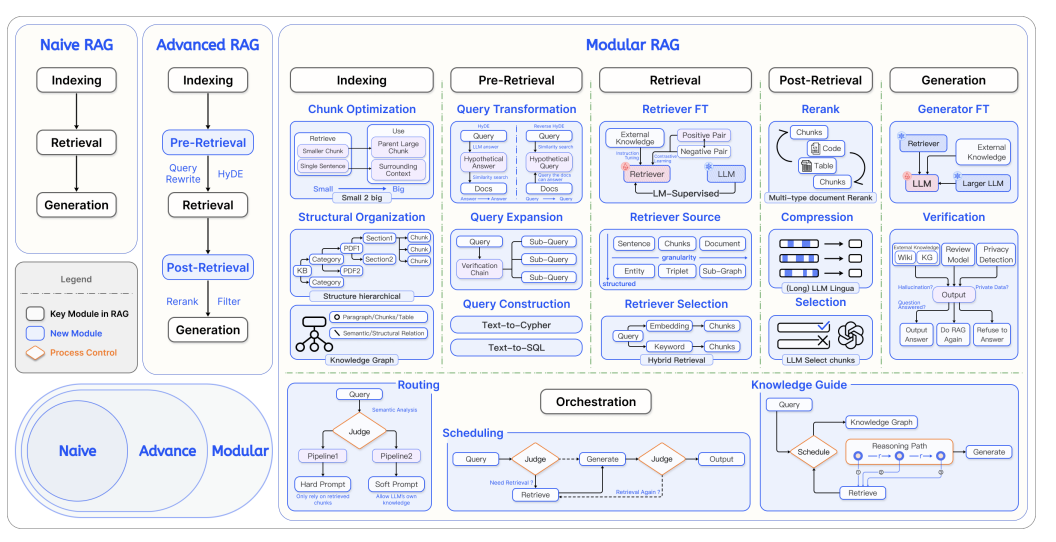

# Modular RAG: 필요한 기능을 조립하는 지능형 구조

RAG가 단일화된 고정 경로(Pipeline)를 벗어나, 마치 레고(LEGO) 블록처럼 자유자재로 구성 요소를 갈아 끼우는 **'모듈형 RAG(Modular RAG)'** 로 진화하였습니다. 이는 정해진 길로만 가는 기차가 아니라, 목적지에 따라 경로를 수정하는 자율주행 자동차와 같은 유연함을 지향합니다.

**시스템의 레고화: 컴포넌트 기반 설계**  
Modular RAG의 핵심은 시스템의 모든 프로세스를 독립적인 단위로 쪼개는 것입니다.

- 독립성: 문서 검색(Retrieval), 답변 생성(Generation), 결과 검증(Evaluation) 등의 각 단계를 별도의 모듈로 분리합니다.

- 맞춤형 조합: 특정 프로젝트에서는 강력한 검색 모듈이 필요하다면 검색 엔진만 업그레이드하고, 다른 프로젝트에서는 요약 능력이 중요하다면 생성 모듈만 최신 모델로 교체하면 됩니다. 전체 시스템을 새로 구축할 필요가 없다는 것이 핵심입니다.

**멀티모달(Multimodal) 대응과 지능적 분기**  
단순히 텍스트를 처리하는 수준을 넘어, Modular RAG는 복합적인 데이터 환경에서 진가를 발휘합니다.

- 데이터 포맷의 자유: 표(Table) 데이터를 분석하여 인사이트를 도출하는 모듈, 이미지(Image)를 인식해 설명글을 생성하는 모듈 등을 파이프라인에 즉시 통합할 수 있습니다.

- 동적 제어: 질문의 난이도나 성격에 따라 "이 질문은 이미지 분석 모듈로 보내라"거나 "이건 외부 API 검색 모듈을 타라"는 식의 조건별 분기 처리가 가능해져 훨씬 지능적인 워크플로우를 구축할 수 있습니다.

**운영 효율성: 확장성, 재사용성, 유지보수**  
개발자와 아키텍트 입장에서 Modular RAG는 운영의 혁신을 가져옵니다.

- 손쉬운 확장: 새로운 AI 기술이나 데이터 형식이 등장해도, 전체 코드를 뜯어고칠 필요 없이 해당 기능을 수행하는 모듈 하나만 추가하면 됩니다.

- 모듈의 재사용: 한 프로젝트에서 공들여 만든 '고성능 검색 모듈'을 다른 서비스나 시스템에 그대로 가져다 쓸 수 있어 개발 생산성이 비약적으로 향상됩니다.

- 관리 편의성: 특정 구간에서 오류가 발생하더라도 해당 모듈만 점검하면 되므로, 시스템 유지보수의 난이도가 획기적으로 낮아집니다.

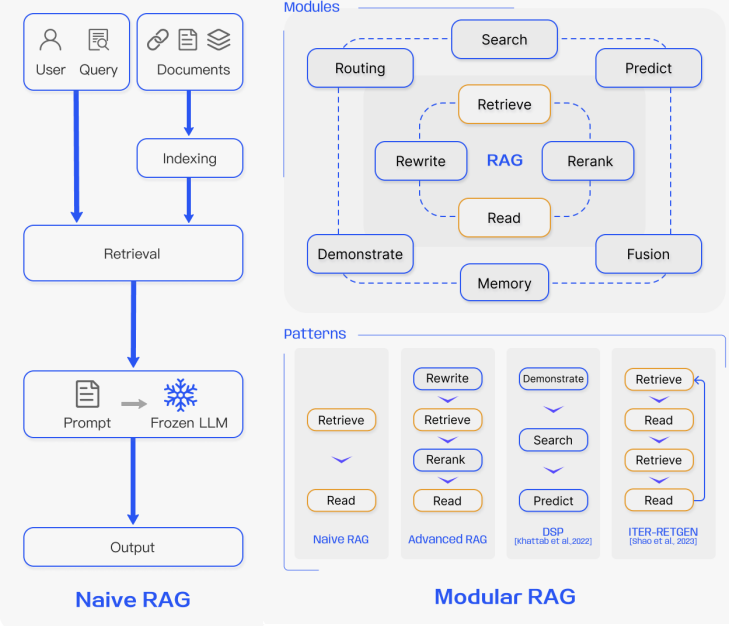

Modular RAG는 고정된 선형 구조를 탈피하여, 특정 기능을 수행하는 **'전문 모듈'** 을 도입하고 이들의 **'상호작용 패턴'** 을 재설계함으로써 범용성과 정밀도를 확보했습니다.

**Modules : 전문 기능의 탑재**  
단순한 검색기와 생성기 외에, 특정 병목 현상을 해결하기 위한 전용 컴포넌트들이 추가되었습니다.

- Search Module: 벡터 유사도 검색에만 의존하지 않고, LLM이 직접 생성한 코드나 쿼리 언어를 통해 검색 엔진, 관계형 데이터베이스(DB), 지식 그래프 등 다양한 데이터 소스에 직접 접근합니다.

- Memory Module: LLM의 자체 기억 능력을 활용합니다. 반복적인 자기 강화(Self-enhancement) 과정을 통해 데이터 분포와 텍스트를 정렬하고, 이를 무한한 메모리 풀처럼 활용하여 검색을 가이드합니다.

- Routing: 유입된 질문의 성격을 분석하여 최적의 경로를 결정합니다. 요약이 필요한지, 특정 DB 검색이 필요한지, 아니면 여러 정보를 병합해야 하는지를 판단하는 '제어 센터' 역할을 합니다.

- Predict Module: 검색 과정에서 발생하는 노이즈와 중복을 줄이기 위해, LLM이 직접 답변에 필요한 맥락을 먼저 생성해 봄으로써 정확도를 보정합니다.

- Task Adapter: 하위 작업(Task)에 맞춰 RAG를 최적화합니다. 제로샷 입력을 위한 프롬프트 자동 인출이나, 퓨샷(Few-shot) 기반의 작업용 검색기를 생성하여 범용성을 높입니다.

Modular RAG 내부를 살펴보면 이런 모양입니다.  
복잡하네요!  

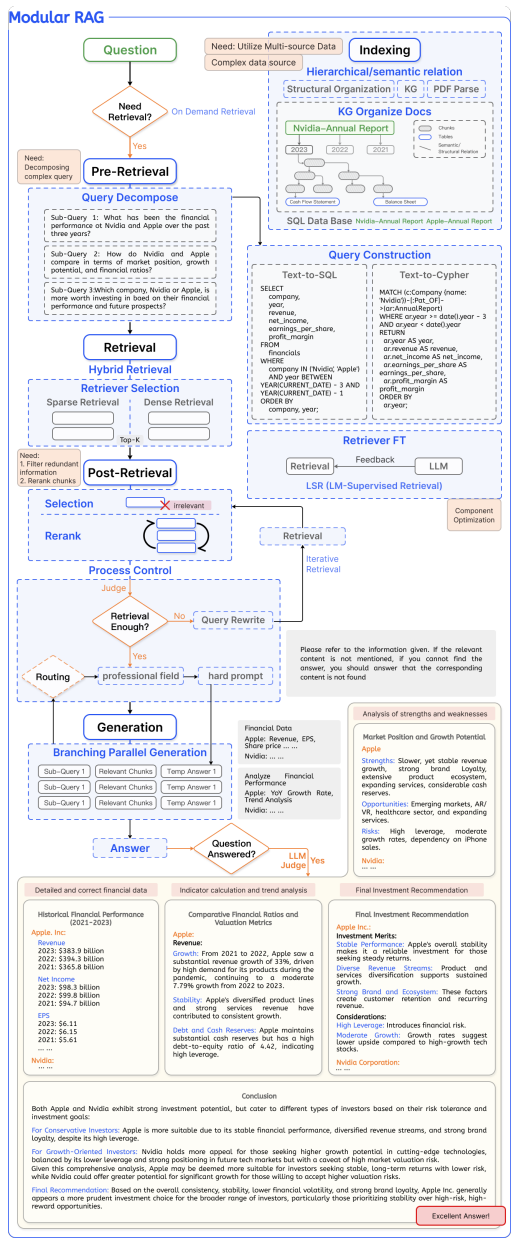

이를 필두로, 모듈 조립을 통한 다양한 패턴들이 소개되었습니다.  

**Patterns : 유연한 흐름의 설계**  
모듈들을 어떻게 배치하고 연결하느냐에 따라 RAG의 성능은 극적으로 변합니다.

- RAG-Fusion (검색 고도화): 사용자의 단일 쿼리를 다각도의 관점으로 확장(Multi-query)한 뒤, 병렬 벡터 검색과 지능적인 **재정렬(Re-ranking)** 을 거쳐 표면적인 정보와 잠재적인 지식을 동시에 발굴합니다.

- Rewrite-Retrieve-Read: 검색 전 질문을 다시 쓰고(Rewrite), 모델의 피드백을 통해 질문 수정 모델을 업데이트하여 검색 효율을 최적화합니다.

- Generate-Read & HyDE: 전통적인 검색 대신 LLM이 생성한 콘텐츠를 활용하거나, **가상 문서 임베딩(HyDE)** 을 통해 실제 문서와 생성된 답변 사이의 임베딩 유사도를 계산하여 관련성을 높입니다.

- DSP & ITER-RETGEN: **'Demonstrate-Search-Predict'** 와 같이 모듈의 출력을 다른 모듈의 입력으로 사용하는 반복적 흐름을 구현하여, 모듈 간의 시너지(Synergy)를 극대화합니다.

**여러 패턴 중 꼭 짚고 넘어가야 하는 패턴은 RAG-Fusion과 Hyde, self-rag 입니다.**

**RAG-Fusion**

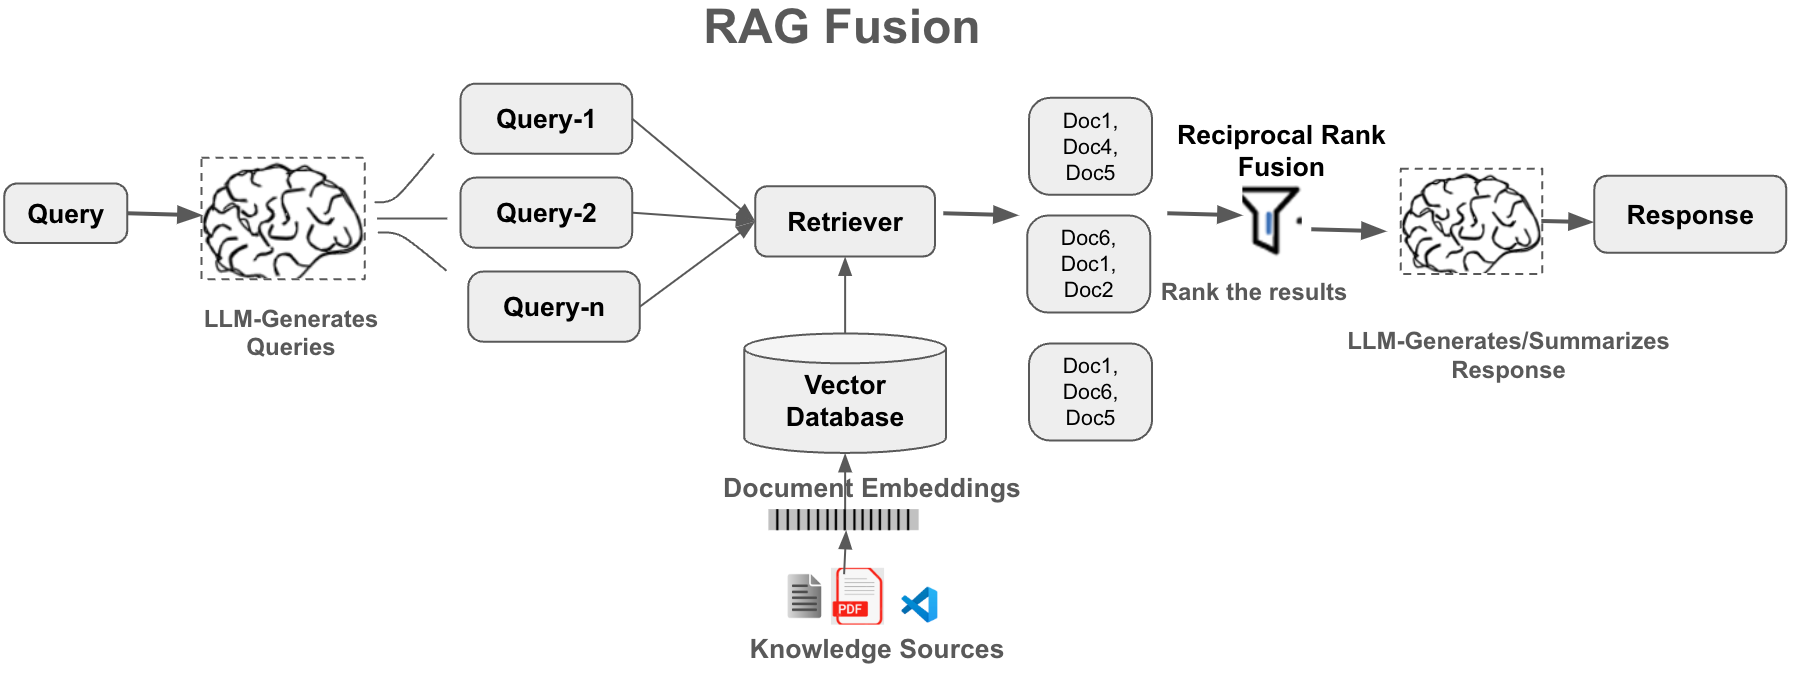

[https://ai.gopubby.com/rag-fusion-redefining-search-using-multi-query-retrieval-and-reranking-88da68783d26]



단순히 문서를 찾는 것에 그치지 않고, '질문 생성 - 다중 검색 - 순위 재조정'이라는 파이프라인을 거칩니다.  
1. 질문의 입체적 확장 (Query Generation): 사용자가 던진 원본 쿼리를 LLM에게 먼저 보냅니다. LLM은 이 질문의 맥락을 분석하여 검색에 유리한 여러 개의 새로운 유사 질문들을 파생시킵니다.  
2. 상호 점수 기반 재순위화 (RRF Scoring): 생성된 각 질문으로 벡터 검색을 수행하여 여러 뭉치의 관련 문서들을 찾아냅니다. 이때 RRF(Reciprocal Rank Fusion) 알고리즘을 적용합니다. 이는 문서의 현재 순위 역수에 스무딩 팩터($k$)를 더해 점수를 매기는 방식($\frac{1}{rank + k}$)으로, 여러 검색 결과에서 공통적으로 상위에 오른 핵심 문서들을 객관적으로 선별해냅니다.  
3. 최종 지식 통합: 재정렬된 최상위 결과물들을 확장된 쿼리들과 함께 다시 LLM에 전달하여, 가장 포괄적이고 정확한 최종 답변을 생성합니다.

**가상의 정답으로 진짜 정답을 찾다: HyDE (Hypothetical Document Embeddings)**

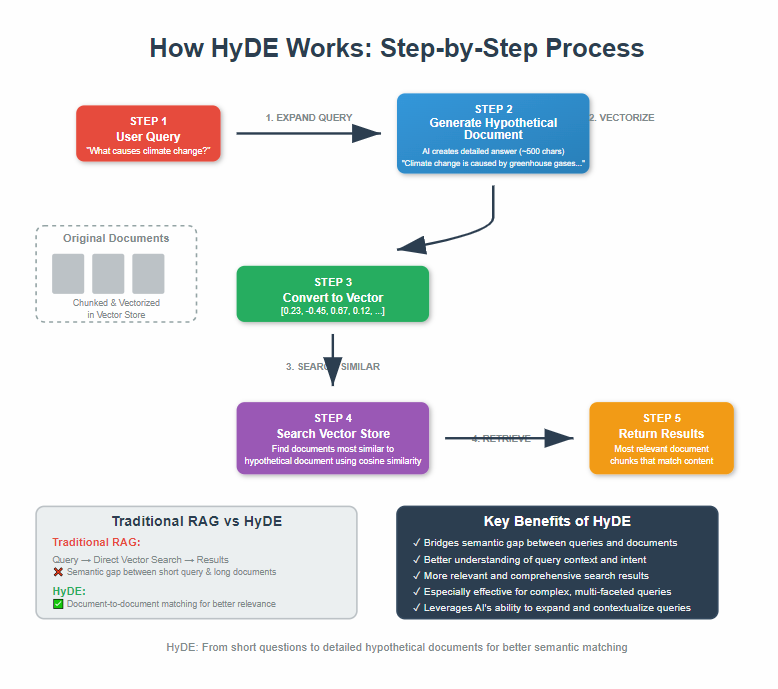

보통의 검색 시스템은 "질문"과 "문서" 사이의 유사도를 계산합니다. 하지만 질문은 짧고 의문문인 반면, 정답이 담긴 문서는 길고 평서문입니다. 이 간극 때문에 검색 효율이 떨어지는 경우가 많습니다. HyDE는 이 문제를 해결하기 위해 **'가짜 정답'** 이라는 징검다리를 놓습니다.

1. HyDE의 독창적인 작동 메커니즘
HyDE는 검색을 수행하기 전, 모델이 스스로 정답을 추측해 보게 만듭니다.

    - 가상 문서 생성 (Generate Hypothetical Document): 사용자의 질문을 받은 LLM은 실제 문서를 찾기 전에, 본인이 아는 지식을 총동원해 "이런 질문이라면 아마 이런 식의 답변 문서가 있을 것"이라며 가상의 정답(Hypothetical Document)을 하나 작성합니다.

    - 임베딩의 전환: 이제 시스템은 사용자의 짧은 질문을 검색하는 대신, LLM이 만든 상세한 가상 답변 문서를 수치화(Embedding)합니다.

    - 진짜 문서 탐색: 가상 답변의 임베딩 값을 기준으로 벡터 DB에서 가장 유사한 진짜 문서를 찾습니다. "질문과 유사한 문서"를 찾는 것보다 "정답과 유사한 문서"를 찾는 것이 훨씬 정확하다는 원리를 이용한 것입니다.

2. 왜 HyDE가 효과적인가?
    - 의미론적 일치: 질문과 정답은 문장 구조가 다르지만, '가상 정답'과 '실제 정답'은 둘 다 평서문 형태이며 사용되는 어휘도 비슷합니다. 따라서 벡터 공간에서 훨씬 더 가깝게 위치하게 됩니다.

    - 검색 품질 개선: 질문이 모호하더라도 LLM이 이를 구체적인 답변 형태로 풀어내기 때문에, 검색 엔진이 훨씬 더 유의미한 맥락을 짚어낼 수 있습니다.

하지만 HyDE 역시 만능은 아닙니다. 만약 LLM이 가상 문서를 만들 때 완전히 틀린 정보를 지어낸다면, 엉뚱한 가짜 답변을 기준으로 검색을 수행하게 되어 결과적으로 전혀 관련 없는 문서를 가져오게 됩니다. 또한 검색을 하기 위해 매번 LLM을 한 번 더 호출해야 하므로, 시간적 지연(Latency)과 API 비용이 발생합니다.

**AI의 자기 성찰: Self-RAG (Self-Reflective RAG)**

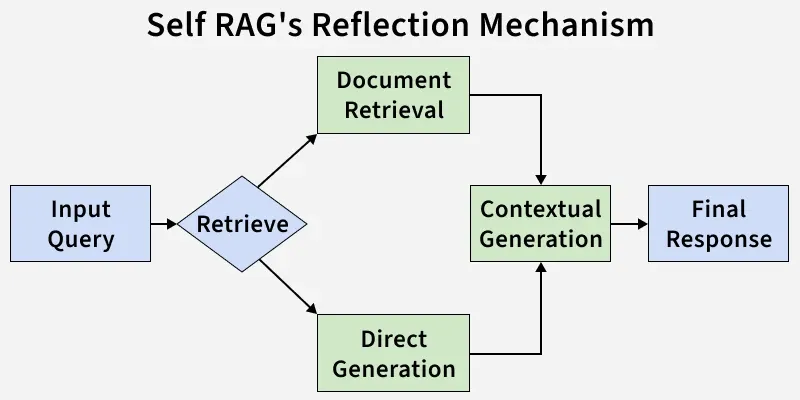

기존의 RAG가 시키는 대로 정보를 찾아오는 '성실한 조수'였다면, Self-RAG는 자신의 작업물을 끊임없이 검토하는 '꼼꼼한 분석가'와 같습니다. 이 기법은 **비평 토큰(Critique Tokens)** 이라는 개념을 도입하여 답변의 신뢰도를 실시간으로 평가합니다.

1. Self-RAG의 지능적 3단계 프로세스
Self-RAG는 답변을 내놓기 전, 내부적으로 다음과 같은 고도의 필터링 과정을 거칩니다.

- 검색 여부 판단 (Is Retrieval Necessary?): 모든 질문에 검색이 필요한 것은 아닙니다. 모델은 먼저 질문을 분석하여 자신이 이미 알고 있는 지식으로 충분한지, 아니면 외부 지식이 필요한지를 결정합니다. 이로 불필요한 검색 비용이 절감됩니다.

- 정보 관련성 평가 (Is it Relevant?): 외부에서 문서를 가져왔다면, 이 문서가 정말 질문에 도움이 되는지 스스로 점수를 매깁니다. 쓸모없는 정보라고 판단되면 과감히 버리고 다시 찾습니다.

- 답변의 근거 검증 (Is it Supported?): 생성된 답변의 문장 하나하나가 실제 가져온 문서(Context)에 기반하고 있는지 검증합니다. 만약 문서에 없는 내용을 지어냈다면(Hallucination), 이를 수정하거나 탈락시킵니다.

Self-RAG는 다음의 주요 기능을 개선시켰습니다.

- 환각 현상의 획기적 감소: 스스로 답변의 근거를 체크하기 때문에, 근거 없는 '아무말 대잔치'를 원천 봉쇄할 수 있습니다.

- 답변 품질 최적화: 여러 개의 답변 후보를 만들고, 그중 비평 토큰 점수가 가장 높은 '최선의 답변'만을 사용자에게 전달합니다.

- 효율적인 자원 관리: 지식 검색이 꼭 필요한 상황에서만 트리거되므로, 전체적인 시스템 부하를 줄일 수 있습니다.

# RAG의 개선 전략  

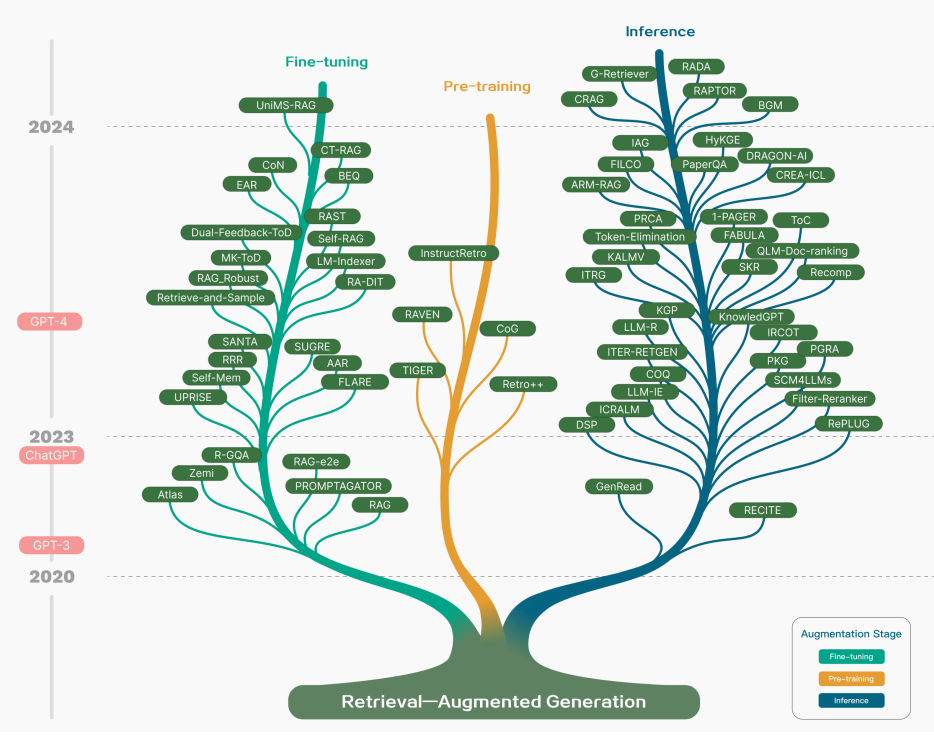

[RAG의 Taxanomy]

지금까지 알아본것과 같이, RAG는 정확한 생성, 정보 보호 및 비용 절감이라는 큰 장점이 있지만, 여러 컴포넌트를 조립한 만큼 단점과 개선책도 많습니다. 위의 여러 기법이 살펴보고 접근한 포인트와 같은, RAG 품질 개선을 위한 전략을 소개합니다.  

## RAG의 개선 전략 : 데이터 구조

데이터 구조에 따른 검색 전략
RAG는 LLM의 능력을 확장하기 위해 외부 지식에 의존합니다. 이때 검색하는 데이터가 비정형, 반정형, 정형 중 어떤 형태냐에 따라 접근 방식이 완전히 달라집니다.

**비정형 데이터 (Unstructured Data): 텍스트의 힘**    
가장 보편적으로 사용되는 소스는 위키피디아, 뉴스, 논문 같은 일반 텍스트 뭉치(Corpus)입니다.

- 범용 지식: 오픈 도메인 질문 답변(ODQA)에서는 위키피디아 덤프가 표준처럼 쓰이며, 최신 정보를 위해 지속적으로 업데이트된 버전이 활용됩니다.

- 도메인 특화: 일반적인 지식 외에도 의료, 법률 등 특정 분야의 전문 텍스트를 활용하여 해당 산업에 최적화된 RAG를 구축할 수 있습니다.  

최근에는 문장을 고정된 길이로 잘라 저장한다기보다, 의미가 끊기지 않도록 하는 기술이 중요해졌습니다.

- Semantic Chunking: 문장을 단순히 글자 수로 자르지 않고, AI가 내용을 분석하여 주제가 바뀌는 지점에서 데이터를 나눕니다.

- Agentic Retrieval: 검색기가 단순히 단어를 찾는 게 아니라, 질문의 의도를 파악해 "이 질문은 뉴스 데이터가 아니라 논문 데이터에서 찾아야 해"라고 스스로 판단하는 에이전트 기술이 결합되고 있습니다.

**반정형 데이터 (Semi-structured Data): PDF와 표의 난제**  

PDF처럼 텍스트와 표(Table)가 섞여 있는 데이터는 전통적인 RAG에게 매우 까다로운 상대입니다.

- 문제점: 텍스트를 자르는 과정에서 표의 구조가 깨지거나, 표 내부의 복잡한 수치 간 관계를 의미론적 유사도만으로 파악하기 어렵기 때문입니다.

- 해결책:
    - Text-to-SQL: LLM의 코딩 능력을 활용해 표를 DB화하고 쿼리로 질문하는 방식(예: TableGPT).

  - 텍스트 변환: 표를 서술형 문장으로 풀어서 인덱싱하는 방식.

하지만 두 방법 모두 완벽하지 않습니다. 이는 최근 Vision Language Model의 도입으로 해결책을 찾고 있습니다.



**정형 데이터 (Structured Data): 지식 그래프(KG)의 정확성**  
검증된 지식을 담고 있는 지식 그래프는 가장 정교한 정보를 제공합니다.

- KnowledGPT: 검색 쿼리를 생성해 지식 베이스(KB)에서 정확한 정보를 인출하고 이를 개인화된 베이스에 저장해 지식의 풍부함을 더합니다.

- G-Retriever: 텍스트 형태의 그래프를 LLM이 이해하기 어려워하는 문제를 해결하기 위해, 그래프 신경망(GNN)과 소프트 프롬프팅 기술을 결합하여 그래프 구조에 최적화된 검색을 수행합니다.

고도의 정확성을 보장하지만, 이러한 정형 데이터베이스를 구축하고 유지보수하는 데 상당한 비용과 노력이 듭니다.
RAG에서의 지식 그래프의 활용은 Microsoft가 발표한 GraphRAG를 통해 큰 전기를 맞이했습니다.  

- 지식의 군집화 (Community Detection): 수천 개의 문서를 그래프로 연결한 뒤, 관련 있는 지식끼리 '커뮤니티'를 형성합니다. 이를 통해 전체 문서에 걸친 포괄적인 질문(예: "이 프로젝트의 전반적인 위험 요소는?")에 대해 일반 RAG보다 훨씬 뛰어난 답변을 내놓습니다.

- 정밀한 관계 추론: 단순 키워드 매칭이 아니라 "A와 B는 부모-자식 관계"라는 논리적 연결 고리를 따라 정보를 추적합니다.

**LLM 생성 콘텐츠 (LLM-Generated Content): 내재적 지식의 재발견**  
외부 데이터가 아닌, LLM이 스스로 생성한 지식을 검색 소스로 활용하는 시도입니다.

- SKR: 질문을 '아는 것'과 '모르는 것'으로 분류해 꼭 필요한 경우에만 검색을 적용합니다.

- GenRead: 외부 검색기 대신 LLM 생성기를 사용합니다. 때로는 LLM이 직접 생성한 맥락이 모델의 학습 목적과 더 잘 맞아서 더 정확한 답을 내놓기도 합니다.

- Selfmem: 모델이 생성한 출력물 중 우수한 것을 메모리 풀에 지속적으로 저장하여, 시간이 갈수록 모델이 스스로 똑똑해지는 '자기 강화' 메커니즘을 구현합니다.  

최근, 모델의 내부 지식을 활용하는 방식은 더욱 정교해졌습니다.

- Self-Refining Knowledge: 검색된 지식이 부족할 경우, LLM이 자신의 내부 지식으로 빈칸을 채운 가상의 문맥을 생성하고, 이를 다시 검색 쿼리로 사용하는 루프 구조가 강화되었습니다.

- Knowledge Distillation: 거대 모델(GPT-4 등)이 생성한 양질의 RAG 데이터를 작은 모델(Llama 3 등)이 학습하게 하여, 비용은 줄이면서 성능은 유지하는 전략이 선호됩니다.

## RAG의 개선 전략 : 인덱싱 최적화

인덱싱은 단순히 문서를 데이터베이스에 넣는 과정이 아니라, LLM이 정답을 가장 찾기 쉬운 형태로 **데이터의 '내비게이션'** 을 설계하는 작업입니다.



**청킹 전략 (Chunking Strategy): 분절에서 의미 단위로**  
데이터를 자르는 '청크(Chunk)'의 크기는 노이즈와 맥락 사이의 줄타기입니다.

- Small-to-Big (부모-자식 인덱싱): 문장 단위로 아주 작게 잘라 검색의 정밀도를 높이되, 실제 모델에게 전달할 때는 앞뒤 문맥(부모 청크)을 통째로 넘겨주는 방식입니다. "검색은 바늘처럼, 답변은 뭉치처럼" 가져오는 것이 핵심입니다.

- Semantic Chunking (최신 트렌드): 고정된 글자 수가 아니라, 텍스트의 의미가 변하는 지점(BERT 등 모델 활용)을 파악해 자릅니다. 문장이 중간에 잘려 맥락이 훼손되는 현상을 방지합니다.

- Sliding Window: 청크 간에 일부분을 겹치게(Overlap) 자르는 고전적 방식이지만, 여전히 문맥의 연속성을 보장하는 가장 안정적인 방법으로 쓰입니다.



**메타데이터 강화 (Metadata Attachments): 데이터에 '속성' 부여하기**  
청크에 날짜, 저자, 제목 등의 정보를 꼬리표로 붙이면 검색의 차원이 달라집니다.

- 시간 인식 RAG (Time-aware RAG): 최신성이 중요한 데이터에 높은 가중치를 부여하여, 구버전의 정보를 필터링하고 최신 지식을 우선적으로 인출합니다.

- 역 HyDE (Reverse HyDE): 문서를 보고 "이 문서가 정답이 될 수 있는 질문들"을 미리 생성해 메타데이터로 저장합니다. 사용자의 질문과 이 '예상 질문'을 대조하면 검색 성능이 비약적으로 상승합니다.

- 요약 메타데이터: 청크 전체 내용을 한 줄 요약해 상위 노드에 저장함으로써 검색의 효율성을 높입니다.


**구조적 인덱스 (Structural Index): 정보의 계층화**  
복잡한 문서일수록 '평면적'인 저장보다 '계층적'인 저장이 유리합니다.

- 계층형 인덱스 (Hierarchical Structure): 요약본(부모) - 상세내용(자식) 구조를 만들어, 먼저 요약본을 훑고 필요한 부분만 깊게 파고들어 데이터를 추출합니다. 이는 모델의 정보 과부하를 막는 최고의 방법입니다.

- Knowledge Graph Index (KG-RAG): 문서 내 개체(Entity)와 개념 간의 관계를 그래프로 연결합니다. "A와 B의 관계는?" 같은 복합 질문에 강하며, 논리적 연결 고리를 따라가기 때문에 환각 현상을 획기적으로 줄입니다.

- KGP (Knowledge Graph Prompting): 여러 문서에 흩어진 정보를 그래프의 노드와 엣지로 연결하여, 다중 문서(Multi-document) 환경에서의 추론 능력을 극대화합니다.

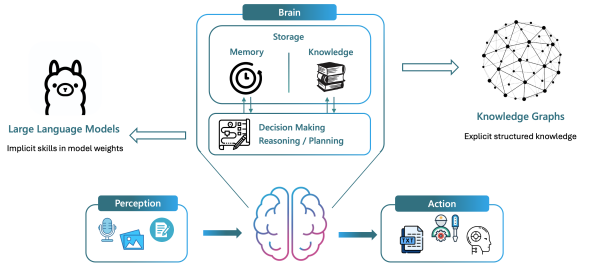

[KG RAG, 인지모듈, 두뇌모듈, 액션모듈 3단계로 구성되어 있으며, 이는 추후에 발현되는 Agentic AI와 매우 흡사합니다]

## RAG의 개선 전략 : 쿼리 최적화

Naive RAG의 가장 큰 약점은 사용자의 질문을 문자 그대로 믿는다는 점입니다. 현실의 질문은 오타가 있거나, 모호하고, 때로는 너무 복잡합니다. 이를 해결하기 위해 질문을 확장, 변형, 유도하는 지능형 필터를 앞단에 배치할 수 있습니다.

**쿼리 확장 (Query Expansion): 정보의 그물망 넓히기**  
단 하나의 키워드에 의존하지 않고, 질문의 외연을 넓혀 관련 정보를 최대한 긁어모으는 전략입니다.

- Multi-Query (다중 쿼리): LLM에게 "이 질문을 검색하기 좋은 3가지 다른 문장으로 만들어줘"라고 시킵니다. 이를 병렬로 검색하여 단어 선택의 차이로 정보를 놓치는 문제를 방지합니다.

- Sub-Query (하위 질문 분할): 복잡한 질문을 여러 개의 원자 단위 질문으로 쪼개는 Least-to-Most 기법을 사용합니다. 예를 들어 "A와 B의 연봉 및 복지 혜택을 비교해줘"를 "A의 연봉", "A의 복지", "B의 연봉", "B의 복지"로 나누어 각각 검색합니다.

- Chain-of-Verification (CoVe): 생성된 확장 질문들이 원본의 의도를 왜곡하지 않았는지 스스로 검증하는 단계를 추가하여, 검색 단계부터 발생할 수 있는 환각(Hallucination)을 차단합니다

**쿼리 변형 (Query Transformation): 검색 최적화 언어로 변환**  
질문의 구조 자체를 검색 엔진(Vector DB)이 가장 좋아하는 형태로 탈바꿈시킵니다.

- Query Rewrite (재작성): 전문 용어나 약어가 섞인 불완전한 질문을 명확한 문장으로 다시 씁니다. 최근에는 Small LM을 활용해 비용은 낮추고 재작성 성능만 극대화하는 추세입니다.

- HyDE & Step-back Prompting: * HyDE: 질문 대신 '가상의 정답'을 만들어 검색합니다.

- Step-back: "이 문제는 어떤 원리에 기반하는가?"와 같이 한 단계 뒤로 물러나 상위 개념을 질문합니다. 원리와 세부 정보를 동시에 검색하여 답변의 깊이를 더합니다.  

최근에는 지식 그래프의 활용 트랜드를 반영한 Query2Doc/Query2Entity 기법이 주목받고 있습니다. 질문에서 핵심 엔티티를 추출하고, 위키피디아 등에서 해당 엔티티의 정의를 미리 가져와 질문에 덧붙임으로써 검색의 맥락을 보강합니다.


**쿼리 라우팅 (Query Routing): 스마트한 교통 관제**  
질문의 성격에 따라 가장 적합한 '전용 도로'로 연결해주는 지능형 분기점입니다.

- Metadata & Semantic Router: 질문 속 키워드나 의미적 유사도를 분석합니다. "어제 뉴스 알려줘"라는 질문은 최신 뉴스 DB로, "우리 회사 규정 알려줘"는 사내 문서 DB로 자동 분류합니다.

- LLM Agent Router: 최근에는 기존의 단순 분류를 넘어, LLM 에이전트가 질문을 보고 "이건 검색이 필요 없어", "이건 Python 코드를 실행해서 계산해야 해", "이건 SQL 쿼리를 날려야 해"라고 판단하여 최적의 툴(Tool)을 선택합니다.

## RAG 개선 전략 : 임베딩

단순히 문서를 자르고 벡터로 바꾸는 것만으로는 부족합니다. 사용자의 복잡한 의도와 전문적인 도메인 지식을 정확히 연결하기 위한 **'검색 품질 고도화'** 의 핵심 관점을 살펴봅니다.



**벡터 검색의 맹점: "의미는 통하지만 키워드를 놓친다"**  
가장 대중적인 '밀집 검색(Dense Retrieval)'은 문장의 전체적인 맥락을 파악하는 데는 뛰어나지만, 두 가지 치명적인 약점이 있습니다.

- 고유명사 및 희귀 용어 취약성: 제품 번호, 특정 법령 번호, 아주 생소한 전문 용어는 벡터 공간에서 적절한 위치를 찾지 못해 검색에서 누락되기 쉽습니다.

- 키워드 일치 무시: 사용자가 "A라는 특정 단어가 포함된 문장을 찾아줘"라고 요구해도, 유사한 의미를 가진 다른 단어가 포함된 문장을 가져오는 경우가 빈번합니다.

이를 해결하기 위해 전통적인 **키워드 기반 검색(BM25)** 과 벡터 기반 검색을 결합, 하이브리드 검색을 도입합니다. 키워드의 '정확성'과 벡터의 '맥락 이해'라는 두 마리 토끼를 잡아, 검색의 견고함(Robustness)을 확보하는 것이 현재의 표준 트렌드입니다.  

**도메인 간극의 문제: "일상어와 전문어의 괴리"**  
일반적인 임베딩 모델은 위키피디아나 뉴스 같은 일반적인 데이터로 학습되었습니다. 하지만 기업 내부의 기술 문서, 의료 데이터, 법률 초안 등은 그들만의 '특수 언어'를 사용합니다. 모델이 보기에 '암세포'와 '악성 종양'은 비슷해 보일 수 있지만, 전문 분야에서는 이들의 미세한 차이가 검색 결과의 성패를 가릅니다.

이 때, 시스템에는 단순히 가져다 쓰는 모델이 아니라, 우리 조직의 데이터를 학습시켜 모델의 '언어 감각'을 교정하는 과정이 필요합니다. 미세 조정(Fine-tuning)을 통한 '도메인 적응'이 그 주요 해법입니다.  

**최신 검색 기술의 지향점: "생성을 위한 검색"**  
과거의 검색은 그저 '관련 있는 문서'를 찾는 것이 목적이었습니다. 하지만 RAG에서는 **'LLM이 답변을 생성하기에 가장 좋은 문서'** 를 찾는 것이 목적이 되어야 합니다.

- 관점의 전환: 질문과 문서의 유사도(Similarity)만 따지는 것이 아니라, 이 문서가 실제로 답변 생성에 얼마나 기여(Reward)하는지를 측정합니다.

- 동적 검색 학습: 최근 트렌드(REPLUG 등)는 LLM이 답변을 생성할 때의 확률 분포를 역으로 추적하여 검색 모델을 개선합니다. 즉, "이 문서를 참고했더니 답변이 잘 나오네?"라는 피드백을 검색 모델에 전달하여 스스로 진화하게 만드는 구조입니다.

## RAG 개선 전략 : 생성

**'Lost in the Middle' 현상: LLM의 고질적 한계 극복**  
최근 연구에 따르면 LLM은 긴 문맥의 처음과 끝은 잘 기억하지만, 중간 부분에 있는 정보는 쉽게 놓치는 경향이 있습니다. 이를 'Lost in the Middle' 문제라고 합니다.

맹점: 단순히 관련 문서 10개를 순서대로 붙여넣는 방식은 중간에 숨겨진 핵심 정보를 버리는 결과를 초래합니다.

개선 관점: 검색된 결과의 '순서'를 재배치하거나 불필요한 정보를 쳐내어 LLM의 시야를 확보해줘야 합니다.

**리랭킹(Reranking): 검색의 질을 결정하는 '최종 면접'**  
1차 검색기(Retriever)가 수만 개의 문서 중 50개를 골라냈다면, 리랭킹 단계에서는 이들을 정밀하게 다시 채점하여 가장 중요한 3~5개만 상단에 배치합니다. 자세한 설명은 앞부분을 참고해주세요!  

관점의 변화: 단순 유사도 점수(Metric)를 넘어, 질문과의 실질적인 연관성(Relevance)과 정보의 다양성(Diversity)을 고려합니다.

트랜드: 최근에는 Cohere Rerank나 BGE-Reranker처럼 리랭킹만을 위해 훈련된 전용 모델을 사용하거나, GPT-4 같은 고성능 LLM에게 직접 순위를 매기게 하는 방식이 대세입니다.

**문맥 압축 및 선택 (Context Compression): 정보의 밀도 높이기**  
"많이 줄수록 좋다"는 것은 RAG의 가장 큰 오해 중 하나입니다. 불필요한 토큰은 비용을 높일 뿐 아니라 답변의 정확도도 떨어뜨립니다.

토큰 다이어트(LLMLingua): 사람이 읽기에는 어색할지라도, LLM은 이해할 수 있는 수준으로 문장을 압축합니다. 불필요한 수식어나 중복된 단어를 제거하여 핵심 정보만 남기는 기술입니다.

정보 응축기(RECOMP): 대조 학습(Contrastive Learning)을 통해 핵심적인 정보(Positive)와 노이즈(Negative)를 구분하도록 학습된 소형 모델(SLM)을 활용하여 컨텍스트를 정제합니다.

**최신 트렌드: '필터-리랭커(Filter-Reranker)' 패러다임**  
최근에는 무거운 LLM과 가벼운 SLM(소형 언어 모델)을 협업시키는 구조가 각광받고 있습니다.

SLM의 역할 (Filter): 방대한 검색 결과 중 명백히 관련 없는 노이즈를 빠르게 1차 필터링합니다.

LLM의 역할 (Reranker & Critic): 살아남은 까다로운 샘플들을 정밀하게 재배열하고, 최종 생성 전 스스로 "이 정보가 정말 답변에 도움이 되는가?"를 비판적으로 검토(Self-Critique)합니다.

## RAG 개선 전략 : 증강

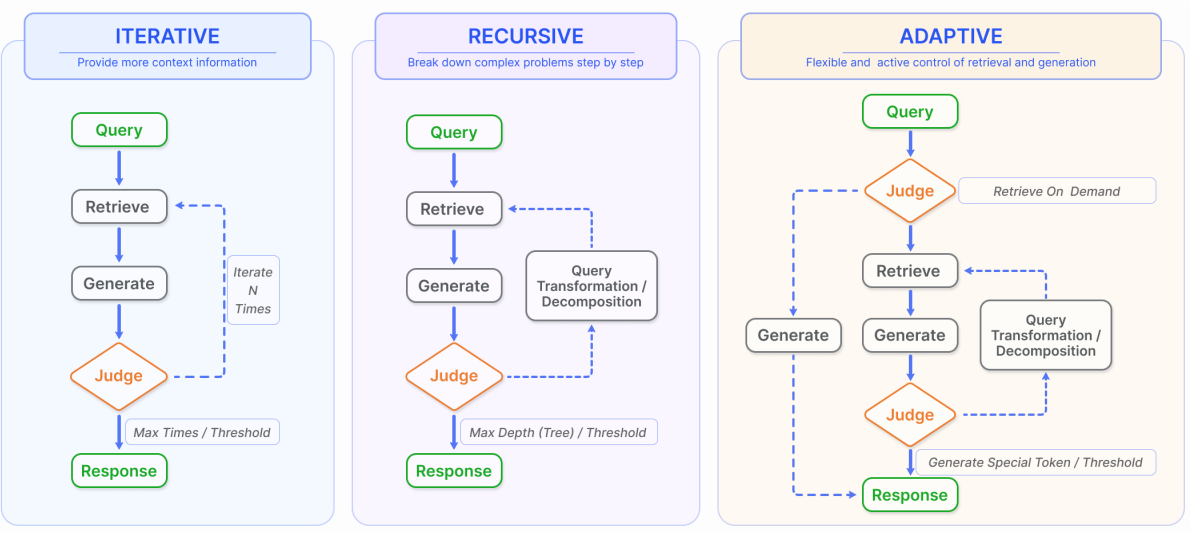

[RAG 패러다임에서 사용중인 여러 증강 방식]

기존 RAG의 가장 큰 맹점은 **'복잡한 추론'** 이 필요한 질문에 취약하다는 것이었습니다. 단 한 번의 검색으로는 질문 뒤에 숨겨진 다각도의 정보를 모두 가져올 수 없기 때문입니다. 이를 극복하기 위해 제안된 증강 전략들은 다음과 같습니다.

**반복적 검색 (Iterative Retrieval): "꼬리에 꼬리를 무는 정보 탐색"**  
한 번의 검색으로 얻은 정보가 불충분할 때, LLM은 빈약한 근거로 답변을 지어내거나(Hallucination), 전체 맥락을 놓치게 됩니다. 이를 개선하기 위해, 답변을 생성하는 과정에서 생성된 텍스트를 기반으로 다시 검색을 수행합니다. 즉, '검색된 정보로 답변을 쓰고, 그 답변을 바탕으로 다시 필요한 정보를 찾는' 선순환 구조를 만듭니다.

**재귀적 검색 (Recursive Retrieval): "검색의 깊이와 정밀도 파악"**  
사용자의 질문이 모호하거나, 문서의 구조가 복잡(예: 수백 페이지의 PDF)할 때 단번에 핵심 위치를 찾기 어렵습니다. 이를 개선하기 위해, 검색 쿼리 자체를 계속해서 정교하게 다듬어 나갑니다.
- 계단식 접근: 먼저 문서 전체의 요약본을 검색하여 위치를 파악한 뒤, 해당 섹션 내부에서 다시 상세 검색을 수행하는 '계층적 구조'를 활용합니다.
- CoT 결합: 모델이 스스로 "이 문제를 풀려면 A를 먼저 찾아야 해"라고 판단하고, A를 찾은 결과에 따라 다음 검색 대상을 결정하는 추론 트리 구조를 형성합니다.

그래프 구조의 데이터나 복잡한 다단계 추론(Multi-hop)이 필요한 문제에서 정답률이 비약적으로 상승합니다.

**적응형 검색 (Adaptive Retrieval): "스스로 판단하는 검색 타이밍"**  
모든 질문에 대해 검색을 수행하는 것은 자원 낭비이며, 때로는 모델이 이미 알고 있는 지식과 외부 지식이 충돌하여 답변의 일관성을 해칩니다. LLM이 '언제 검색이 필요한지' 스스로 결정하게 만드는 것으로 이를 개선합니다.

- 확신도 기반 제어: 답변을 생성하다가 자신이 생성하는 단어의 확률(Confidence)이 낮아지면 "아, 여기서부터는 내 지식이 부족해. 검색이 필요해!"라고 판단하여 검색기를 호출합니다.

- 자기 성찰(Self-Reflection) 토큰: 모델 내부에 '검색(Retrieve)'이나 '비판(Critic)'과 같은 특수 토큰을 두어, 외부 정보를 가져올지 혹은 가져온 정보가 유용한지를 스스로 평가하며 답변을 수정해 나갑니다.

## Hightlights : SoTA RAG  

단순히 텍스트 조각을 찾아오는 시대를 지나, 이제 RAG는 정보 사이의 관계를 이해하고(Graph), 스스로 추론하여 도구를 사용하는(Agentic) 단계로 진화하고 있습니다. 기존 RAG가 가진 '연결성'과 '자율성'의 한계를 극복하여, 이후 Agent 패러다임으로 진화하게 됩니다.

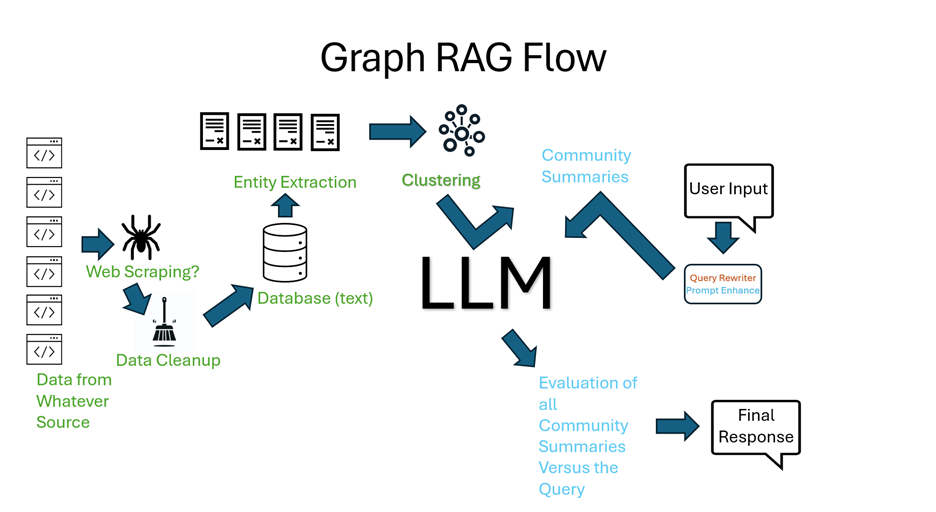

**지식의 지도를 그리는 기술: Graph RAG**  
기존의 벡터 기반 검색(Vector RAG)은 텍스트를 고정된 크기의 조각(Chunk)으로 나누어 수치화하는 방식에 의존해 왔습니다. 하지만 이러한 방식은 텍스트 속에 숨겨진 복잡한 개체 간의 관계를 보존하지 못한다는 근본적인 한계가 있습니다. 예를 들어, 수백 페이지에 달하는 소설이나 복잡한 기업 보고서에서 서로 다른 챕터에 등장하는 인물이나 사건들의 연결 고리를 파악하려면, 단순히 '유사한 단어'를 찾는 것만으로는 부족합니다. 여기서 등장한 것이 바로 Graph RAG입니다.

Graph RAG는 텍스트 데이터를 벡터로 바꾸기 전, 언어 모델을 활용하여 데이터 속에 존재하는 주요 개체(Entity)와 그들 사이의 관계(Relationship)를 먼저 추출합니다. 이렇게 추출된 정보는 점(Node)과 선(Edge)으로 연결된 지식 그래프(Knowledge Graph) 형태로 데이터베이스에 저장됩니다. 이 과정이 중요한 이유는 정보를 '파편화된 조각'이 아닌 '유의미한 네트워크'로 재구성하기 때문입니다.

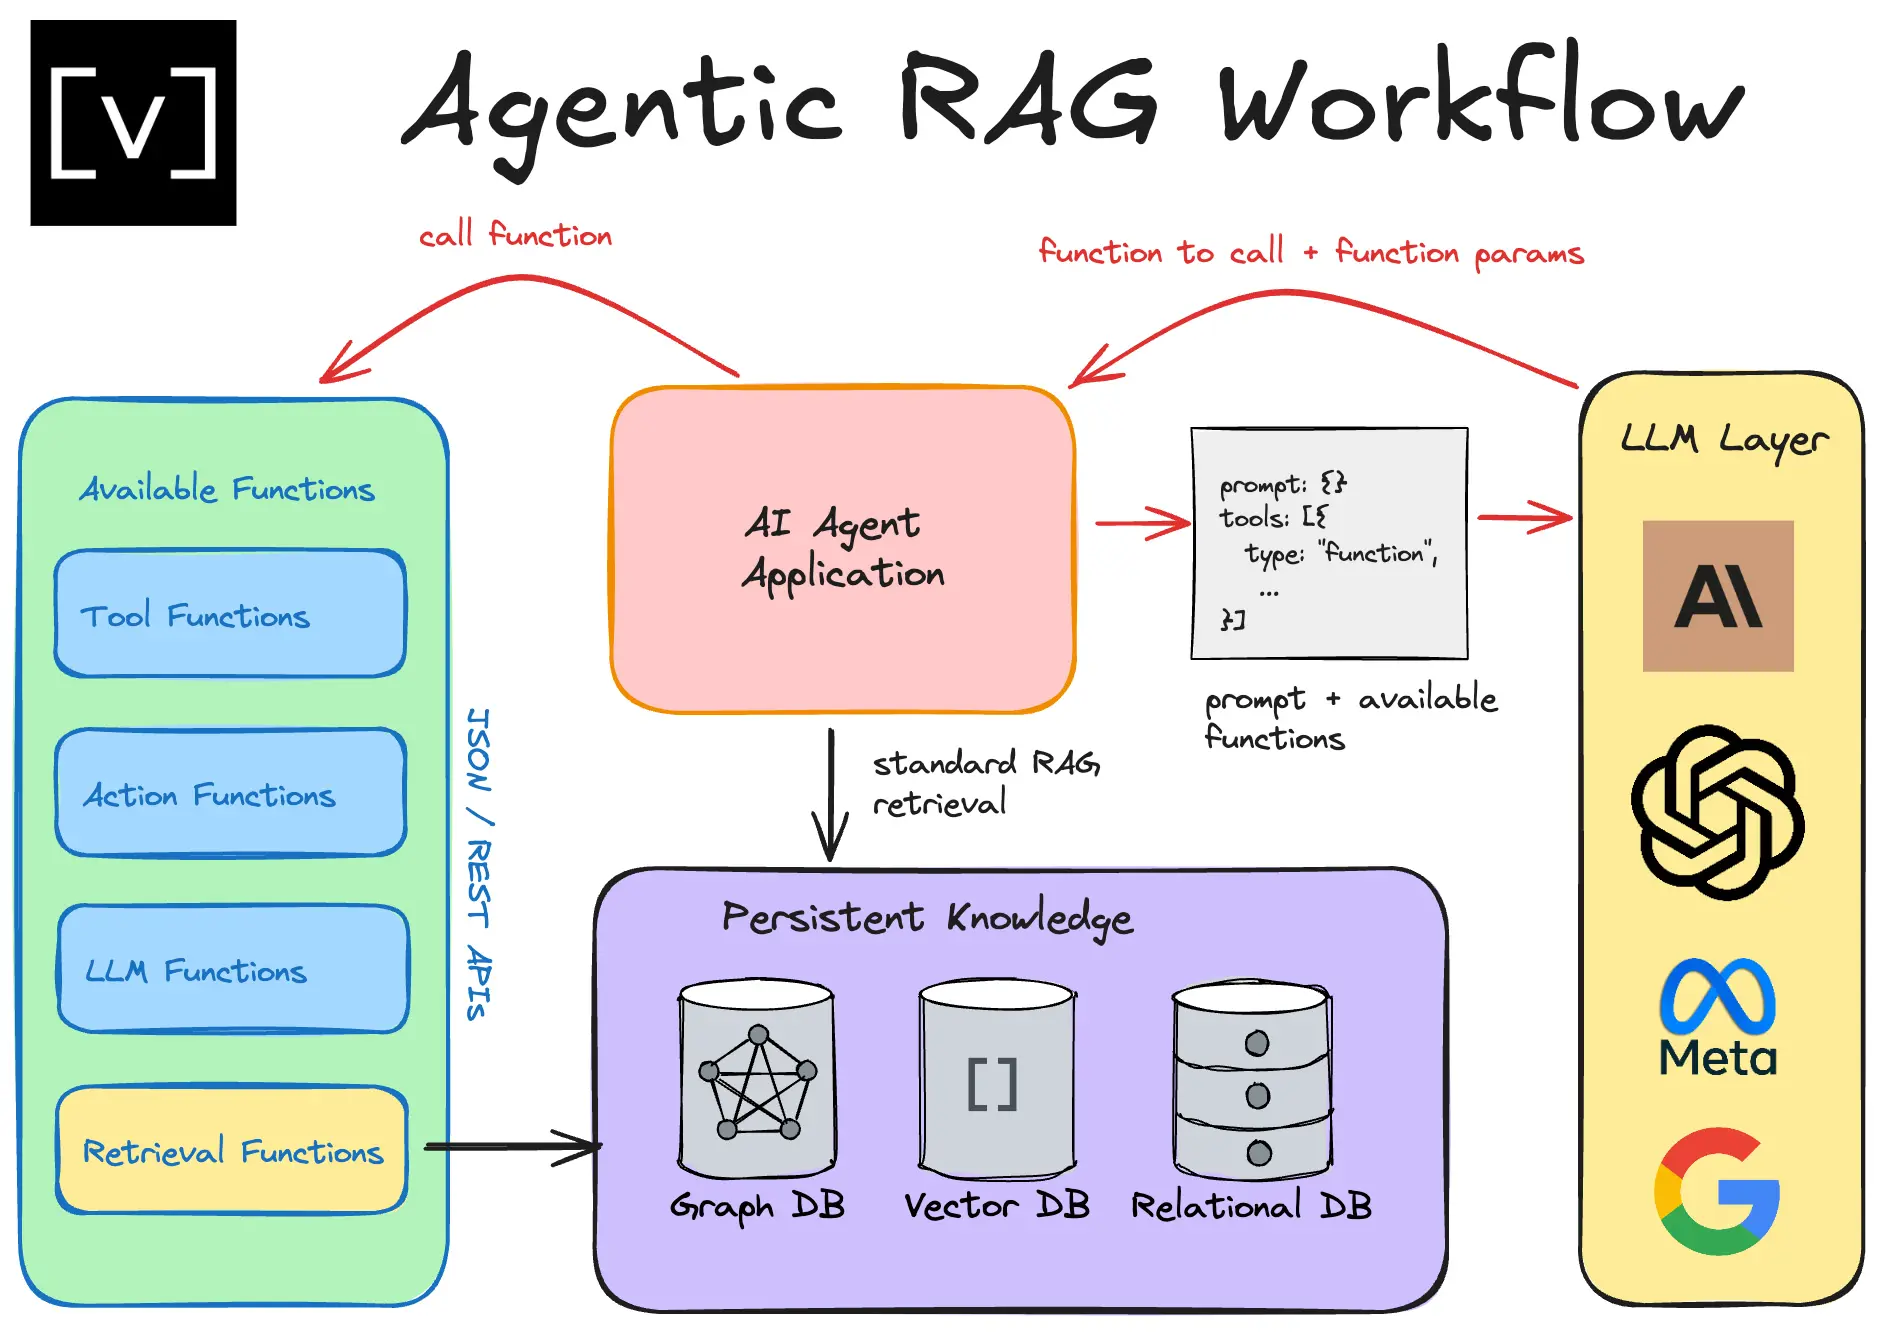

**자율적 사고를 가진 검색 에이전트: Agentic RAG**  
RAG 시스템의 또 다른 진화 방향은 시스템의 '자율성'에 있습니다. 초기 RAG는 사용자가 질문하면 검색기가 문서를 찾고 생성기가 답을 하는 일방통행 구조였습니다. 하지만 실전 환경에서의 질문은 그리 단순하지 않습니다. 어떤 질문은 검색이 전혀 필요 없기도 하고, 어떤 질문은 한 번의 검색만으로는 도저히 해결되지 않는 연쇄적인 탐색을 요구합니다. Agentic RAG는 이러한 경직된 파이프라인을 깨고, LLM에게 일종의 '판단력'과 '도구 사용권'을 부여한 형태입니다.

Agentic RAG의 핵심은 LLM이 단순한 텍스트 생성기를 넘어, 문제를 해결하는 기획자(Planner)이자 실행가(Executor) 역할을 수행한다는 점입니다. 사용자의 질문이 들어오면 에이전트는 먼저 '계획'을 세웁니다. "이 질문은 우리 회사 규정도 찾아봐야 하고, 최신 법령도 웹에서 검색해봐야겠군"이라고 판단하는 식입니다. 이후 에이전트는 벡터 데이터베이스, 웹 검색 엔진, SQL 데이터베이스 등 자신이 가진 여러 '도구' 중 최적의 것을 선택하여 필요한 정보를 수집합니다.

이 과정에서 가장 주목받는 기술적 트렌드는 '자기 성찰(Self-Reflection)'과 '다단계 루프'입니다. 에이전트는 검색된 결과가 질문에 충분히 답변할 수 있는지 스스로 검토하며, 만약 정보가 부족하거나 신뢰도가 낮다고 판단되면 검색 쿼리를 수정하여 다시 시도합니다. 이는 기존의 수동적인 검색 방식에서 발생하던 '잘못된 문서에 기반한 오답 생성'을 획기적으로 줄여줍니다. 또한, 긴 워크플로우를 관리하기 위해 상태(State)를 유지하며 복잡한 태스크를 하나씩 해결해 나가는 구조로 발전하고 있습니다. 결국 Agentic RAG는 단순한 Q&A 시스템을 넘어, 사용자의 복잡한 요구사항을 자율적으로 처리하는 '지능형 비서'로의 진화를 의미합니다.

### Reference  
https://arxiv.org/pdf/2312.10997